# Resort Guest Churn Prediction

This notebook walks through the full pipeline we built to predict which resort guests are likely to cancel.
One notebook covering the full pipeline end to end.

**The goal:** given what we know about a guest (age, booking type, spending, loyalty points, etc.),
predict whether they will churn (1) or stay (0).

**Metric:** F1 score (balances precision and recall, good for binary classification).

## 1. Setup & Imports

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # quiet mode — only show errors

RANDOM_STATE = 42
TARGET = "Churned"
ID_COL = "GuestID"
SPEND_COLS = ["RoomService", "Dining", "Retail", "Spa", "Entertainment"]

DATA_DIR = Path("data")

print("All imports OK")

All imports OK


## 2. Load the Data

In [13]:
train = pd.read_csv(DATA_DIR / "resort_train.csv")
test  = pd.read_csv(DATA_DIR / "resort_test.csv")

print(f"Train: {train.shape[0]:,} rows  x  {train.shape[1]} columns")
print(f"Test:  {test.shape[0]:,} rows  x  {test.shape[1]} columns")
train.head()

Train: 6,954 rows  x  21 columns
Test:  1,739 rows  x  20 columns


,GuestID,BookingDate,PromoCode,Region,AllInclusive,Room,PackageType,Age,VIP,RoomService,...,Retail,Spa,Entertainment,LoyaltyPoints,SurveyScore,DaysSinceEmail,BookingChannel,AgeGroup,ReferralSource,Churned
0,619623,2024-02-10,NaN,Americas,0.0,G/630/S,Relaxation,0.0,0.0,0.0,...,0.0,0.0,0.0,6915,5,136,Website,NaN,Facebook,1
1,776250,2024-01-03,NaN,Americas,1.0,G/201/S,Relaxation,17.0,0.0,0.0,...,0.0,0.0,0.0,8571,5,362,Corporate,Minor,Billboard,1
2,932709,2023-01-17,NaN,Americas,NaN,G/1483/S,Wellness,35.0,0.0,0.0,...,0.0,0.0,0.0,1142,4,154,TravelAgent,Middle,Facebook,0
3,771839,2023-12-09,PromoA,Europe,1.0,D/164/S,Adventure,26.0,0.0,0.0,...,0.0,NaN,0.0,9642,2,128,Website,Young,Magazine,1
4,755501,2024-02-15,PromoA,Americas,0.0,G/818/P,Relaxation,13.0,0.0,0.0,...,60.0,1.0,5147.0,5528,4,35,Mobile,Minor,Google,0


## 3. Quick Exploratory Analysis

Before touching the data, let's get a feel for what we're working with.

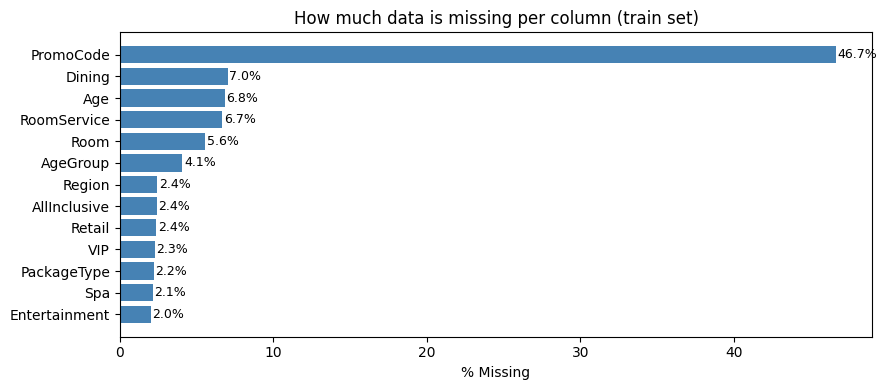

In [14]:
# --- Missing values ---
# Some columns have gaps. Good to know before we clean anything.
missing_pct = (train.isna().sum() / len(train) * 100).sort_values()
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(missing_pct.index, missing_pct.values, color="steelblue")
ax.set_xlabel("% Missing")
ax.set_title("How much data is missing per column (train set)")
for i, v in enumerate(missing_pct.values):
    ax.text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

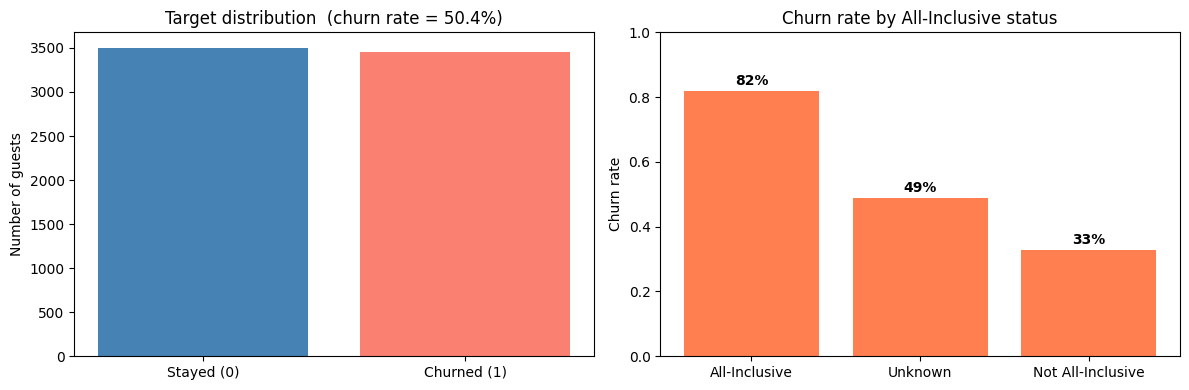

In [15]:
# --- Target balance ---
# How many guests actually churned vs stayed?
churn_counts = train[TARGET].value_counts()
churn_rate = train[TARGET].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: raw counts
axes[0].bar(["Stayed (0)", "Churned (1)"], churn_counts.values, color=["steelblue", "salmon"])
axes[0].set_title(f"Target distribution  (churn rate = {churn_rate:.1%})")
axes[0].set_ylabel("Number of guests")

# Right: churn rate by All-Inclusive package
# This is one of the strongest signals in the data
ai_labels = {0.0: "Not All-Inclusive", 1.0: "All-Inclusive"}
ai_churn = (
    train.assign(AI=train["AllInclusive"].map(ai_labels).fillna("Unknown"))
    .groupby("AI")[TARGET].mean()
    .sort_values(ascending=False)
)
axes[1].bar(ai_churn.index, ai_churn.values, color="coral")
axes[1].set_ylabel("Churn rate")
axes[1].set_ylim(0, 1)
axes[1].set_title("Churn rate by All-Inclusive status")
for i, v in enumerate(ai_churn.values):
    axes[1].text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

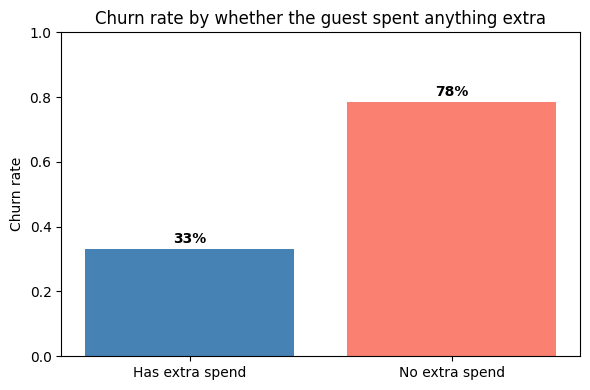

In [16]:
# --- Does extra spending predict churn? ---
# Guests who spent on things like dining or spa behave differently from those who didn't touch anything.
total_spend = train[SPEND_COLS].sum(axis=1)
has_spend = (total_spend > 0).map({True: "Has extra spend", False: "No extra spend"})
spend_churn = train.groupby(has_spend)[TARGET].mean()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(spend_churn.index, spend_churn.values, color=["steelblue", "salmon"])
ax.set_ylabel("Churn rate")
ax.set_ylim(0, 1)
ax.set_title("Churn rate by whether the guest spent anything extra")
for i, v in enumerate(spend_churn.values):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

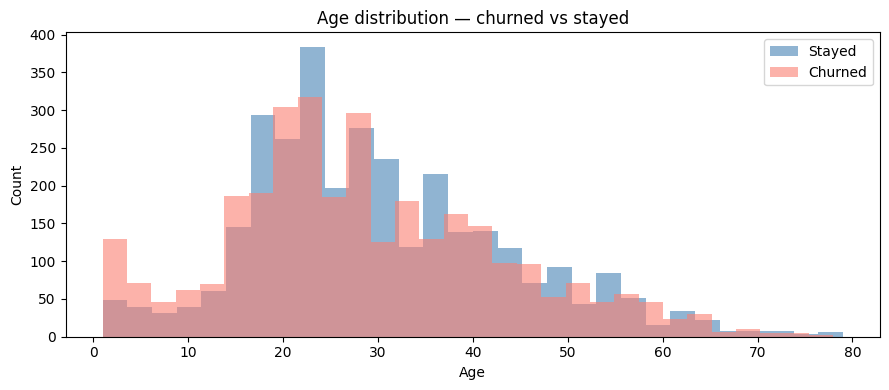

In [17]:
# --- Age distribution by churn ---
# Note: Age == 0 in the raw data is actually a data error (missing age), so we filter those out here.
age_data = train[train["Age"] > 0].dropna(subset=["Age"])

fig, ax = plt.subplots(figsize=(9, 4))
for label, color in [(0, "steelblue"), (1, "salmon")]:
    subset = age_data[age_data[TARGET] == label]["Age"]
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=f"{'Churned' if label else 'Stayed'}")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
ax.set_title("Age distribution — churned vs stayed")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Data Cleaning

A few issues need to be fixed before we can model. We apply the same rules to train and test
by combining them, cleaning once, then splitting back — this guarantees they're treated identically.

In [18]:
# Combine train + test so cleaning rules fire exactly the same way on both
train["__split"] = "train"
test["__split"] = "test"
test[TARGET] = np.nan
full = pd.concat([train, test], ignore_index=True)

# PromoCode: NaN just means "no promo was used" — give it a label so the model sees it
full["PromoCode"] = full["PromoCode"].fillna("None")

# Age == 0 is a data entry error (138 guests recorded as age 0).
# We replace with NaN so CatBoost handles them as truly missing.
full.loc[full["Age"] == 0, "Age"] = np.nan

# AllInclusive has a NaN group that actually churns at a different rate than True or False.
# Keeping it as "unknown" lets the model treat it as its own category.
full["AllInclusive"] = (
    full["AllInclusive"]
    .map({0: "False", 1: "True", 0.0: "False", 1.0: "True"})
    .fillna("unknown")
)

# For the other text columns, missing means the data wasn't captured.
# "Unknown" is more informative than a blank and keeps the missingness signal alive.
for col in ["Region", "PackageType", "BookingChannel", "ReferralSource", "AgeGroup"]:
    full[col] = full[col].fillna("Unknown")

# Parse booking date so we can extract the month later
full["BookingDate"] = pd.to_datetime(full["BookingDate"], errors="coerce")

print(f"Combined shape: {full.shape}")
print(f"No Age==0 rows left: {(full['Age'] == 0).sum()}")
print(f"AllInclusive levels: {full['AllInclusive'].unique()}")

Combined shape: (8693, 22)
No Age==0 rows left: 0
AllInclusive levels: <ArrowStringArray>
['False', 'True', 'unknown']
Length: 3, dtype: str


## 5. Feature Engineering

The raw columns don't tell the full story. We build ~10 new features that the EDA told us are meaningful.

In [19]:
# --- Spend features ---
# Whether a guest spent anything at all is a stronger signal than the spend amount itself.
full["Total_Spend"] = full[SPEND_COLS].sum(axis=1, skipna=True)
full["HasAnySpend"] = (full["Total_Spend"] > 0).astype(int)

# --- The single biggest interaction in the data ---
# Europe + All-Inclusive guests churn at ~99%. This concatenated feature lets the
# model split on that combination directly rather than needing two separate splits.
full["AllInclusive_Region"] = full["AllInclusive"] + "_" + full["Region"]

# --- Room features ---
# Room codes look like "G/1483/S" — that's wing / floor number / view type.
room_parts = full["Room"].str.split("/", expand=True)
full["Wing"] = room_parts[0].fillna("Unknown")
full["View"] = room_parts[2].fillna("Unknown")
full["Floor"] = pd.to_numeric(room_parts[1], errors="coerce")

# Raw floor number is meaningless across wings (wing A goes up to floor 107,
# wing F goes up to 1893). We normalize it within each wing so it's on a 0-1 scale.
wing_max = full.groupby("Wing")["Floor"].transform("max")
full["Floor_relative"] = full["Floor"] / wing_max

# --- Missingness flags ---
# Guests with missing Age or Room have noticeably higher churn rates,
# so we want the model to know when that data is absent.
full["Age_was_missing"] = full["Age"].isna().astype(int)
full["Room_was_missing"] = full["Room"].isna().astype(int)

# --- Date features ---
full["Booking_Month"] = full["BookingDate"].dt.month

# --- Engagement ---
# A quick composite: high survey score + recent email engagement = engaged guest.
# Subtract DaysSinceEmail so stale contacts pull the score down.
full["Engagement_Score"] = full["SurveyScore"] * 100 - full["DaysSinceEmail"]

print("Feature engineering done.")
print(f"Columns now: {full.shape[1]}")

Feature engineering done.
Columns now: 33


In [20]:
# Split back into train and test
clean_train = full[full["__split"] == "train"].drop(columns=["__split"]).reset_index(drop=True)
clean_test  = full[full["__split"] == "test"].drop(columns=["__split", TARGET]).reset_index(drop=True)

# Define which columns go into the model
CAT_FEATURES = [
    "Region", "PackageType", "BookingChannel", "ReferralSource",
    "PromoCode", "AllInclusive", "Wing", "View", "AgeGroup", "AllInclusive_Region"
]
NUM_FEATURES = [
    "Age", "LoyaltyPoints", "SurveyScore", "DaysSinceEmail", "VIP",
    "RoomService", "Dining", "Retail", "Spa", "Entertainment",
    "Total_Spend", "HasAnySpend", "Floor_relative",
    "Age_was_missing", "Room_was_missing", "Booking_Month", "Engagement_Score"
]
FEATURE_COLS = NUM_FEATURES + CAT_FEATURES

# CatBoost needs categorical columns to be strings
X = clean_train[FEATURE_COLS].copy()
y = clean_train[TARGET].astype(int)
X_test = clean_test[FEATURE_COLS].copy()

for col in CAT_FEATURES:
    X[col] = X[col].astype(str)
    X_test[col] = X_test[col].astype(str)

print(f"Feature matrix: {X.shape}")
print(f"Categorical features ({len(CAT_FEATURES)}): {CAT_FEATURES}")

Feature matrix: (6954, 27)
Categorical features (10): ['Region', 'PackageType', 'BookingChannel', 'ReferralSource', 'PromoCode', 'AllInclusive', 'Wing', 'View', 'AgeGroup', 'AllInclusive_Region']


## 6. Train a Baseline Model

We use CatBoost — it handles categorical features and missing values natively, which saves a lot of preprocessing.

5-fold cross-validation means we train 5 models, each on 80% of the data and evaluated on the remaining 20%.
The average F1 across those 5 folds is our reliable estimate of how well the model generalises.

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
baseline_fold_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostClassifier(
        random_seed=RANDOM_STATE,
        verbose=0,
        cat_features=CAT_FEATURES,
        thread_count=-1
    )
    model.fit(X_tr, y_tr)

    preds = model.predict(X_val)
    score = f1_score(y_val, preds)
    baseline_fold_scores.append(score)
    print(f"  Fold {fold + 1}:  F1 = {score:.4f}")

baseline_f1 = np.mean(baseline_fold_scores)
print(f"\nBaseline CV F1: {baseline_f1:.4f}")

  Fold 1:  F1 = 0.8269
  Fold 2:  F1 = 0.8528
  Fold 3:  F1 = 0.8210
  Fold 4:  F1 = 0.8355
  Fold 5:  F1 = 0.8413

Baseline CV F1: 0.8355


## 7. Hyperparameter Tuning with Optuna

The default CatBoost settings are already solid, but we can squeeze out a bit more performance
by searching over a few key settings. We use Optuna to run 25 trials automatically and pick the best.

We only tune 3 parameters to keep things fast and readable:
- `depth` — how deep each decision tree can grow
- `learning_rate` — how big each correction step is
- `iterations` — how many trees to build

In [22]:
def objective(trial):
    params = {
        "depth":         trial.suggest_int("depth", 4, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "iterations":    trial.suggest_int("iterations", 100, 600),
        "random_seed":   RANDOM_STATE,
        "verbose":       0,
        "cat_features":  CAT_FEATURES,
        "thread_count":  -1,
    }

    # Use 3-fold inside Optuna to keep each trial fast
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for tr_idx, val_idx in inner_cv.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        m = CatBoostClassifier(**params)
        m.fit(X_tr, y_tr)
        scores.append(f1_score(y_val, m.predict(X_val)))

    return np.mean(scores)


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25, show_progress_bar=True)

print(f"\nBest hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(f"\nBest 3-fold F1 from Optuna: {study.best_value:.4f}")
print(f"Baseline 5-fold F1 was:     {baseline_f1:.4f}")

  0%|          | 0/25 [00:00<?, ?it/s]


Best hyperparameters:
  depth: 4
  learning_rate: 0.07893985721444766
  iterations: 294

Best 3-fold F1 from Optuna: 0.8333
Baseline 5-fold F1 was:     0.8355


## 8. Evaluate

We train the tuned model on 80% of the training data and evaluate it on the held-out 20%.
This gives us concrete charts showing where the model is right and wrong.

In [23]:
# Hold out 20% of train for evaluation charts
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

eval_model = CatBoostClassifier(
    **study.best_params,
    random_seed=RANDOM_STATE,
    verbose=0,
    cat_features=CAT_FEATURES,
    thread_count=-1
)
eval_model.fit(X_tr, y_tr)

preds = eval_model.predict(X_val)
probs = eval_model.predict_proba(X_val)[:, 1]

val_f1 = f1_score(y_val, preds)
print(f"Validation F1 (tuned, 80/20 split): {val_f1:.4f}")

Validation F1 (tuned, 80/20 split): 0.8118


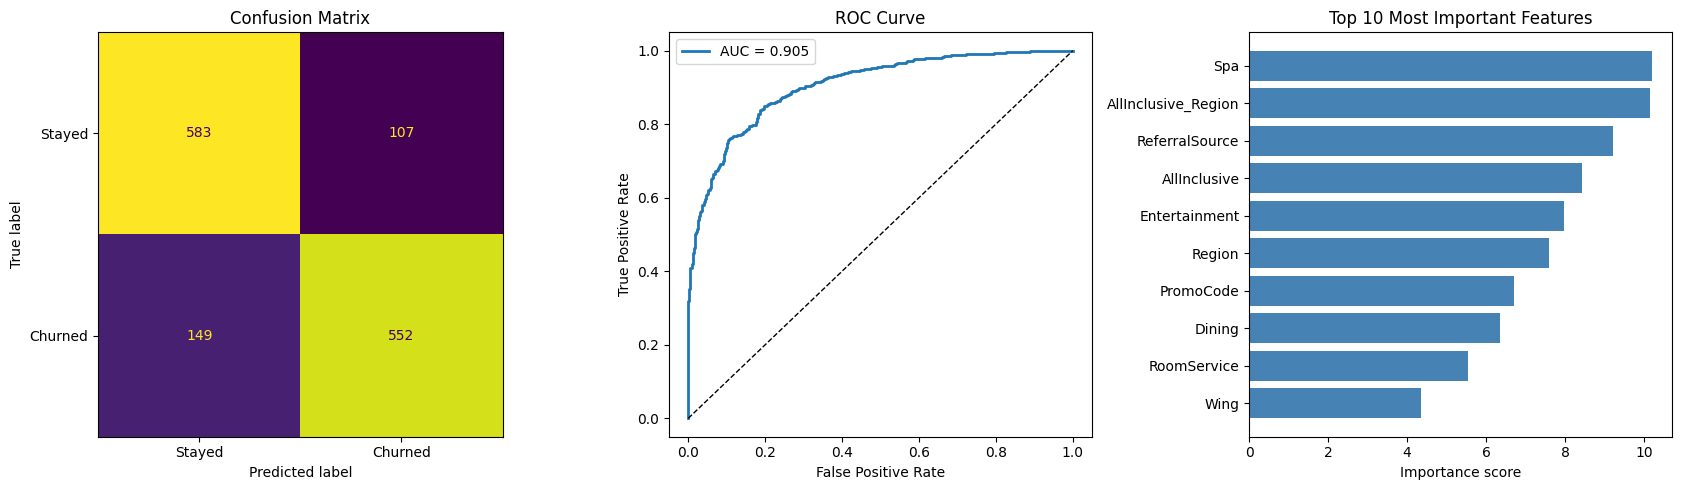

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Confusion matrix ---
# Rows = actual, columns = predicted. We want the diagonal to be high.
cm = confusion_matrix(y_val, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed", "Churned"])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

# --- ROC Curve ---
# AUC closer to 1.0 means the model ranks churners above non-churners more reliably.
fpr, tpr, _ = roc_curve(y_val, probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

# --- Feature Importance ---
# Which features did the model rely on the most?
importances = pd.Series(
    eval_model.get_feature_importance(),
    index=FEATURE_COLS
).nlargest(10).sort_values()

axes[2].barh(importances.index, importances.values, color="steelblue")
axes[2].set_xlabel("Importance score")
axes[2].set_title("Top 10 Most Important Features")

plt.tight_layout()
plt.show()

## 9. Make Predictions

Now we retrain the tuned model on the **full** training set (all 6,954 guests) and predict on the test set.
The threshold is 0.50 — if the model gives a guest a probability above 50%, we predict churn.

In [25]:
# Train on all available labeled data
final_model = CatBoostClassifier(
    **study.best_params,
    random_seed=RANDOM_STATE,
    verbose=0,
    cat_features=CAT_FEATURES,
    thread_count=-1
)
final_model.fit(X, y)

# Predict on the test set using the standard 0.50 threshold
test_probs = final_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= 0.50).astype(int)

# Build the submission file
submission = clean_test[[ID_COL]].copy()
submission[TARGET] = test_preds
submission.to_csv("submission.csv", index=False)

print(f"Saved submission.csv  ({len(submission)} rows)")
print(f"Predicted churn rate on test set: {submission[TARGET].mean():.1%}")
submission.head(10)

Saved submission.csv  (1739 rows)
Predicted churn rate on test set: 48.2%


,GuestID,Churned
0,154038,1
1,620160,0
2,655103,0
3,126993,0
4,635228,0
5,844514,0
6,541503,1
7,787572,1
8,645651,0
9,849608,1
